# Lab №2

## Выполнение

### 0. Импортируем необходимые библиотеки

In [1]:
# Import required libraries for mathematical operations, robotics modeling, and plotting
from math import pi
import numpy as np
import roboticstoolbox as rtb
import matplotlib.pyplot as plt
import spatialmath.base as sb

### 1. Импортируем модель UR3

In [2]:
# Load UR3 robot model from Robotics Toolbox then display robot DH parameters
robot = rtb.models.DH.UR3()
print(robot)

DHRobot: UR3 (by Universal Robotics), 6 joints (RRRRRR), dynamics, standard DH parameters
┌─────┬─────────┬─────────┬────────┐
│ θⱼ  │   dⱼ    │   aⱼ    │   ⍺ⱼ   │
├─────┼─────────┼─────────┼────────┤
│  q1 │  0.1519 │       0 │  90.0° │
│  q2 │       0 │ -0.2437 │   0.0° │
│  q3 │       0 │ -0.2132 │   0.0° │
│  q4 │  0.1124 │       0 │  90.0° │
│  q5 │ 0.08535 │       0 │ -90.0° │
│  q6 │  0.0819 │       0 │   0.0° │
└─────┴─────────┴─────────┴────────┘

┌──┬──┐
└──┴──┘

┌──────┬───────┬─────┬─────┬─────┬──────┬─────┐
│ name │ q0    │ q1  │ q2  │ q3  │ q4   │ q5  │
├──────┼───────┼─────┼─────┼─────┼──────┼─────┤
│   qr │  180° │  0° │  0° │  0° │  90° │  0° │
│   qz │  0°   │  0° │  0° │  0° │  0°  │  0° │
└──────┴───────┴─────┴─────┴─────┴──────┴─────┘



1. Let's define the mass of the links

In [3]:
robot.links[0].m = 2.00
robot.links[1].m = 3.42
robot.links[2].m = 1.26
robot.links[3].m = 0.80
robot.links[4].m = 0.80
robot.links[5].m = 0.35


2. Let's define the center of mass of each link

In [4]:
robot.links[0].r = [0.0, -0.02, 0.0]
robot.links[1].r = [0.13, 0.0, 0.1157]
robot.links[2].r = [0.05, 0.0, 0.0238]
robot.links[3].r = [0.0, 0.0, 0.01]
robot.links[4].r = [0.0, 0.0, 0.01]
robot.links[5].r = [0.0, 0.0, -0.02]

3. Let's define the inertia tensor of each link. Filling: [Lxx, Lyy, Lzz, Lxy, Lyz, Lxz]

Note:
Some dynamic parameters (inertia, friction, gear ratios) are assumed
due to lack of complete manufacturer data and are used for simulation purposes.

In [5]:
robot.links[0].I = [0.0060, 0.0050, 0.0040, 0, 0, 0]
robot.links[1].I = [0.0300, 0.0280, 0.0060, 0, 0, 0]
robot.links[2].I = [0.0100, 0.0090, 0.0030, 0, 0, 0]
robot.links[3].I = [0.0020, 0.0020, 0.0010, 0, 0, 0]
robot.links[4].I = [0.0020, 0.0020, 0.0010, 0, 0, 0]
robot.links[5].I = [0.0004, 0.0004, 0.0003, 0, 0, 0]

4. Let's set the moment of inertia of the drive

In [6]:
robot.links[0].Jm = 2.0e-4
robot.links[1].Jm = 2.0e-4
robot.links[2].Jm = 1.5e-4
robot.links[3].Jm = 8.0e-5
robot.links[4].Jm = 8.0e-5
robot.links[5].Jm = 5.0e-5


5. Let's define the coefficient of viscous friction of the drive

In [7]:
robot.links[0].B = 0.0010
robot.links[1].B = 0.0010
robot.links[2].B = 0.0008
robot.links[3].B = 0.0004
robot.links[4].B = 0.0004
robot.links[5].B = 0.0002

6. Let's define the coefficient of Coulomb friction of the drive

In [8]:
robot.links[0].Tc = [0.020, -0.020]
robot.links[1].Tc = [0.020, -0.020]
robot.links[2].Tc = [0.015, -0.015]
robot.links[3].Tc = [0.008, -0.008]
robot.links[4].Tc = [0.008, -0.008]
robot.links[5].Tc = [0.005, -0.005]

7. Let's set the gear ratio for each link

In [9]:
robot.links[0].G = 80
robot.links[1].G = 80
robot.links[2].G = 70
robot.links[3].G = 50
robot.links[4].G = 50
robot.links[5].G = 40

8. Let's set restrictions on the generalized coordinates for each link

In [10]:
robot.links[0].qlim = [-2*pi, 2*pi]
robot.links[1].qlim = [-2*pi, 2*pi]
robot.links[2].qlim = [-2*pi, 2*pi]
robot.links[3].qlim = [-2*pi, 2*pi]
robot.links[4].qlim = [-2*pi, 2*pi]
robot.links[5].qlim = [-2*pi, 2*pi]

### 2. Зададим начальное положение робота и построим его

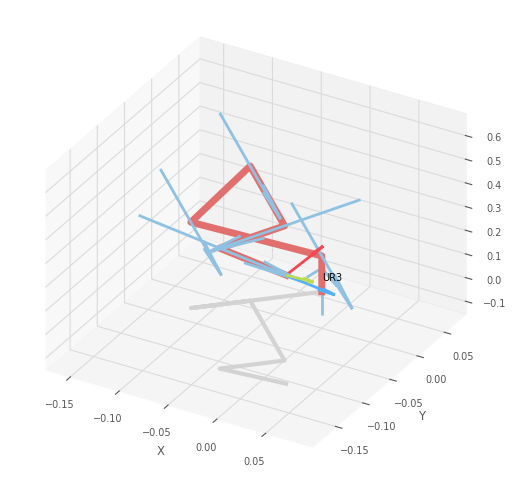

<Figure size 640x480 with 0 Axes>

In [11]:
#Set an arbitrary initial robot configuration
q_start = [np.pi/4, -np.pi/3, -np.pi/4, np.pi/3, -np.pi/3, np.pi/4]
robot.plot(q_start)
plt.show()

### 3. Решим прямую задачу кинематики

In [12]:
#Solve the forward kinematics problem for the given generalized coordinates
T_start = robot.fkine(q_start)
print(T_start)

   0.09732   0.6098    0.7866    0.05407   
   0.9633   -0.2562    0.07946  -0.1627    
   0.25      0.75     -0.6124    0.4584    
   0         0         0         1         



### 6. Построим рабочую зону манипулятора

Инициализируем переменные

In [13]:
n = 20  # Количество точек по каждой оси
i = 0  # Просто счетчик
move = [np.linspace(robot.links[i].qlim[0], robot.links[i].qlim[1], n) for i in range(3)]  # Записываем пределы перемещения для первых трех звеньев
pose = np.zeros([3,n**3])  # Создаем пустой массив для записи данных

Рассчитываем рабочую зону

In [14]:
# Проходимся перебором по каждой точке
for q1 in move[0]:
    for q2 in move[1]:
        for q3 in move[2]:
            Tt = robot.fkine([q1,q2,q3,0,0,0])  # Решаем ПЗК, меняя только первые 3 обобщенных координаты
            for j in range(3):
                pose[j][i] = Tt.t[j]  # Сохраняем точку
            i += 1

Строим рабочую зону

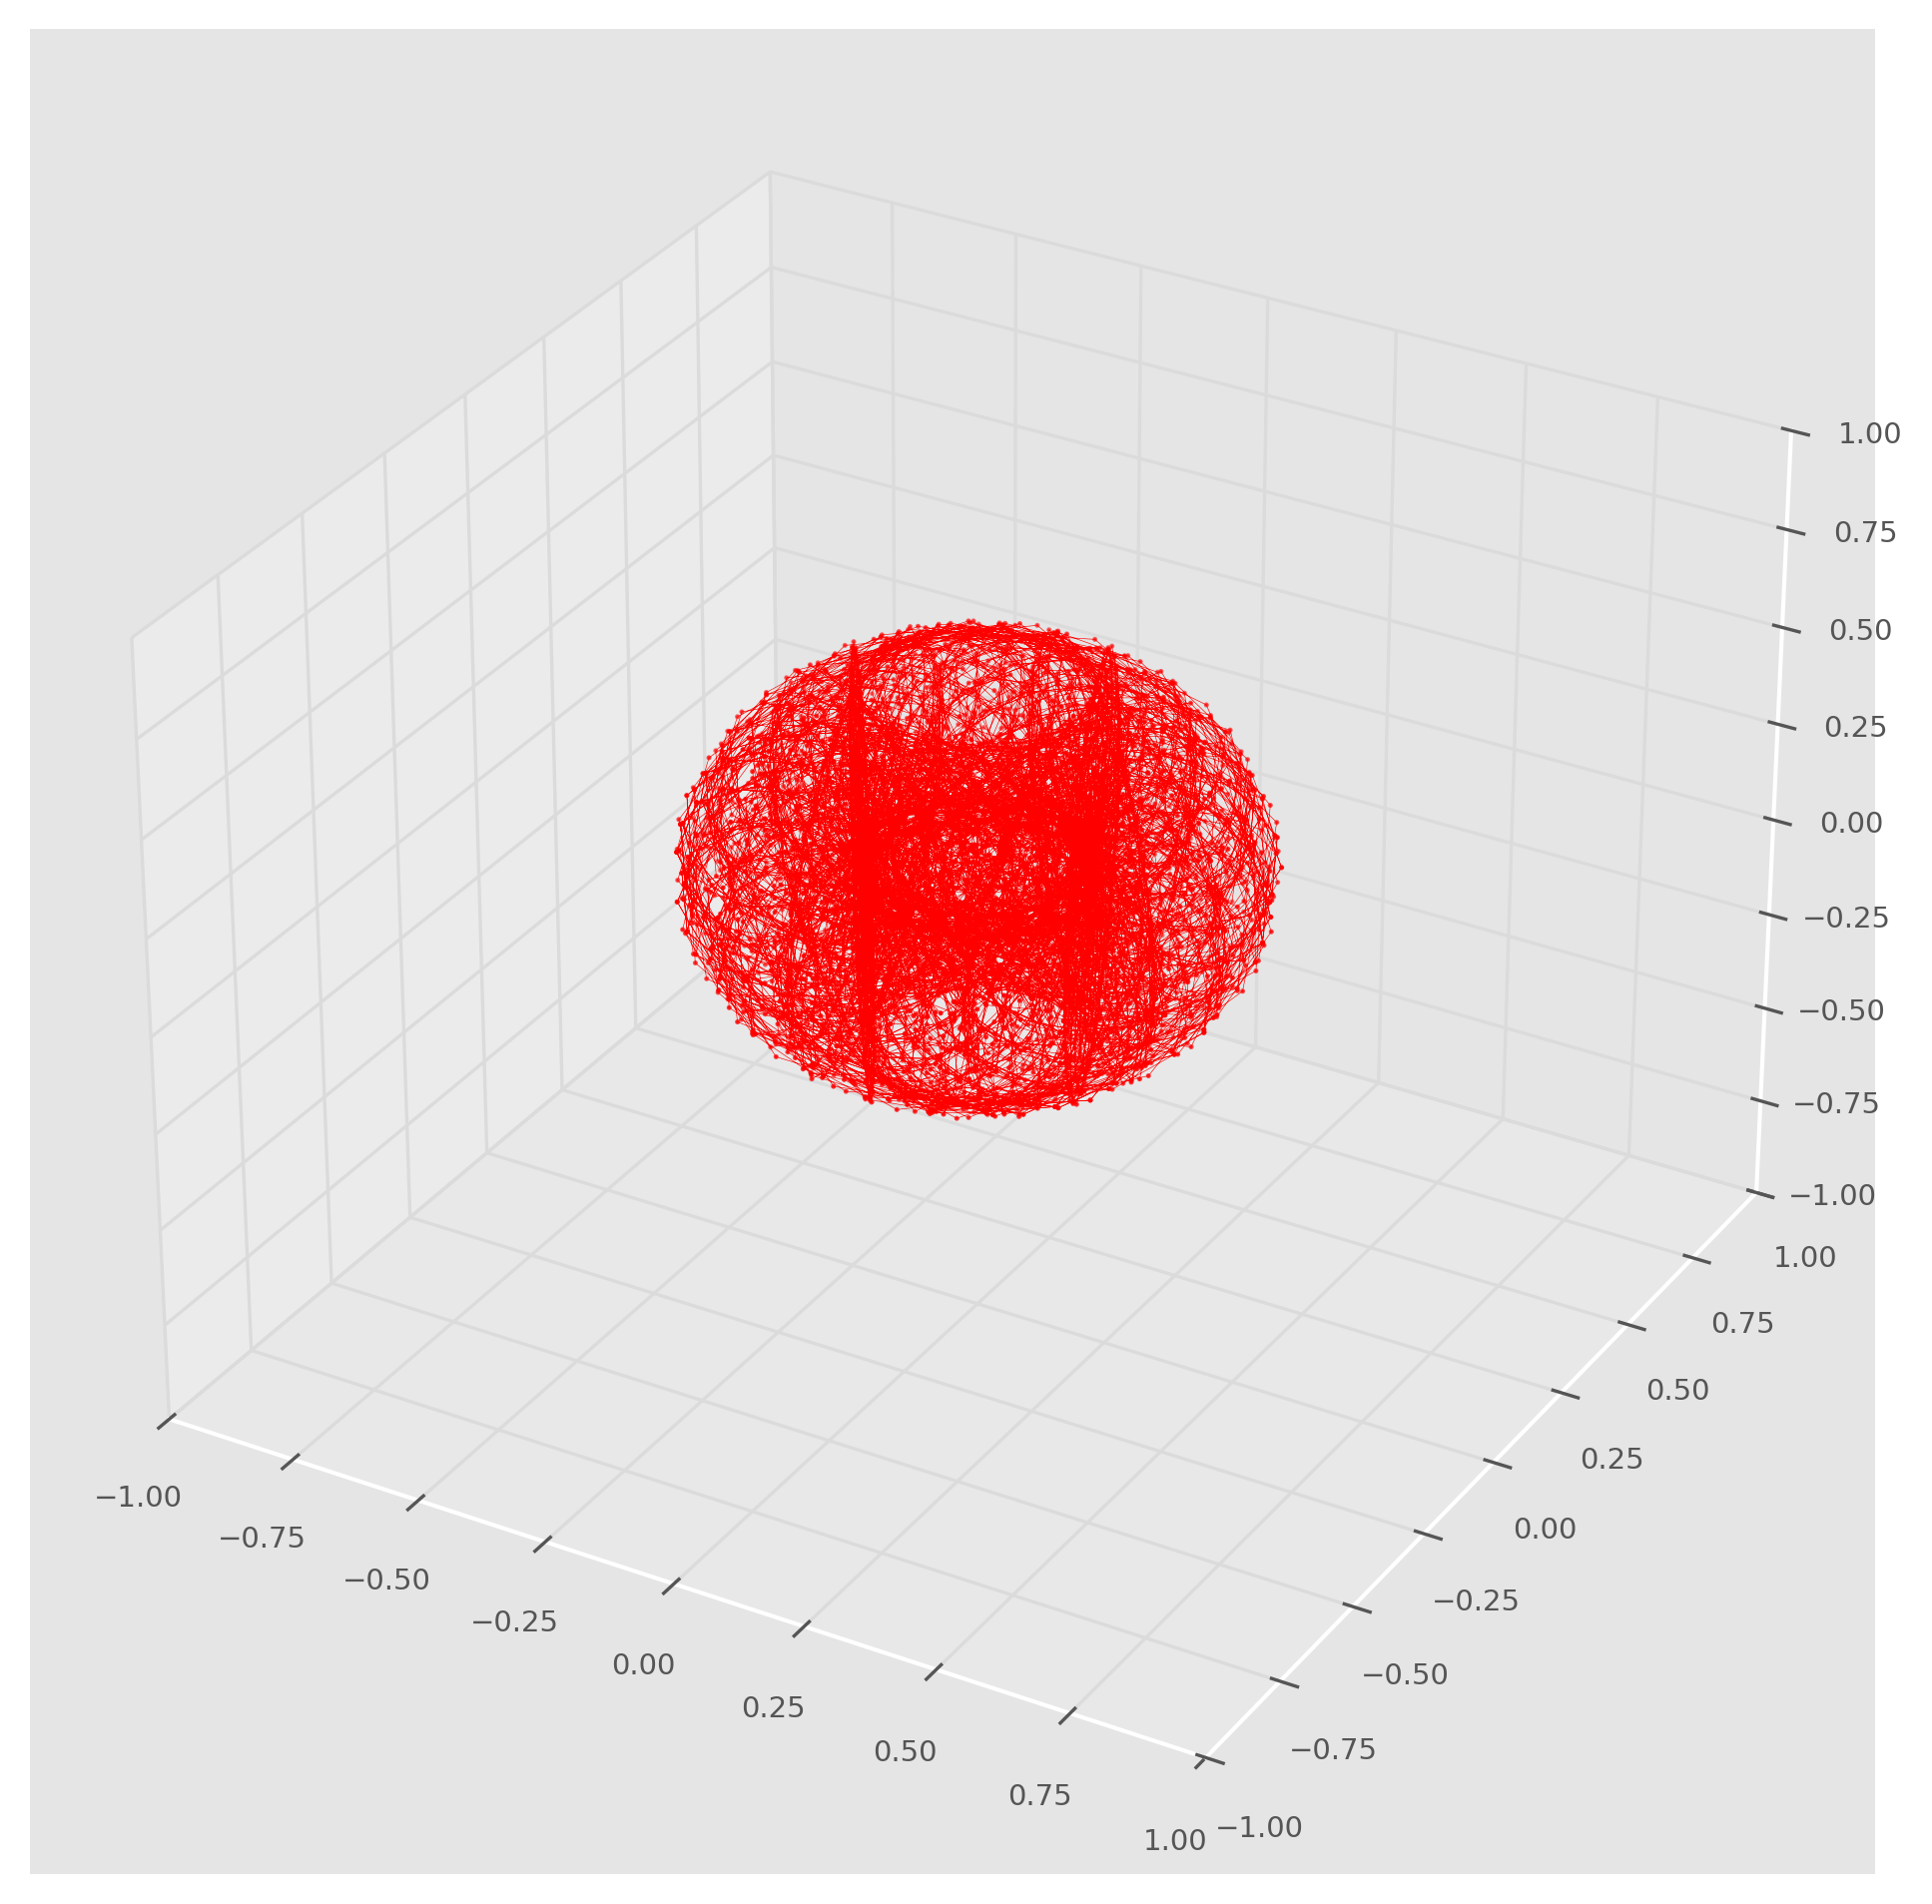

In [15]:
#Construct the manipulator's workspace under the given joint constraints
plt.figure(figsize=(8,8), dpi=300)
ax = plt.axes(projection="3d")
ax.plot3D(pose[0], pose[1], pose[2], color='red', linewidth=0.15)
ax.scatter3D(pose[0], pose[1], pose[2], s=0.5, color='red')
ax.set_xlim(-1,1)
ax.set_ylim(-1,1)
ax.set_zlim(-1,1)
plt.show()

### 7. Выберем конечную точку и проверим её (решим обратную задачу кинематики)

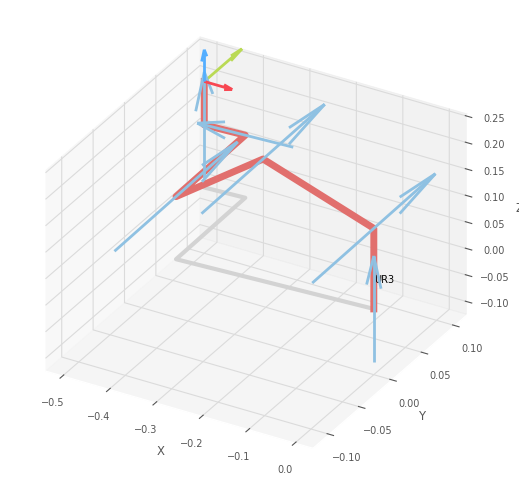

   1        -5.169e-11 -5.516e-10 -0.5       
   5.169e-11  1         3.669e-09  0.1       
   5.516e-10 -3.669e-09  1         0.2       
   0         0         0         1         



<Figure size 640x480 with 0 Axes>

In [16]:
#Select end point within the workspace and solve the inverse kinematics problem for it
point = [-0.5,0.1,0.2]
T_end = sb.transl(point)
q_end = robot.ikine_GN(T_end).q  # Есть другие методы, помимо ikine_GN
robot.plot(q_end)
T_verify = robot.fkine(q_end)
print(T_verify)
plt.show()

### 8. Спланируем траекторию

Спланируем траекторию методом 'jtraj' для $N$ = 100 точек

In [17]:
#Plan the trajectory between the initial and final positions of the manipulator's end-effector using at least three planning methods
N = 100
t_start = 0
t_stop = 5
t_shag = t_stop/N
time = np.arange(t_start, t_stop, t_shag)

tr_jtraj = rtb.jtraj(q_start, q_end, time)

Спланируем ту же траекторию методом 'mtraj' с функцией 'trapezoidal'

In [18]:
tr_trap = rtb.mtraj(rtb.trapezoidal, q_start, q_end, time)

Спланируем ту же траекторию методом 'mtraj' с функцией 'quintic'

In [19]:
tr_quin = rtb.mtraj(rtb.quintic, q_start, q_end, time)

### 9. Построим графики

Построим графики положений для каждого звена

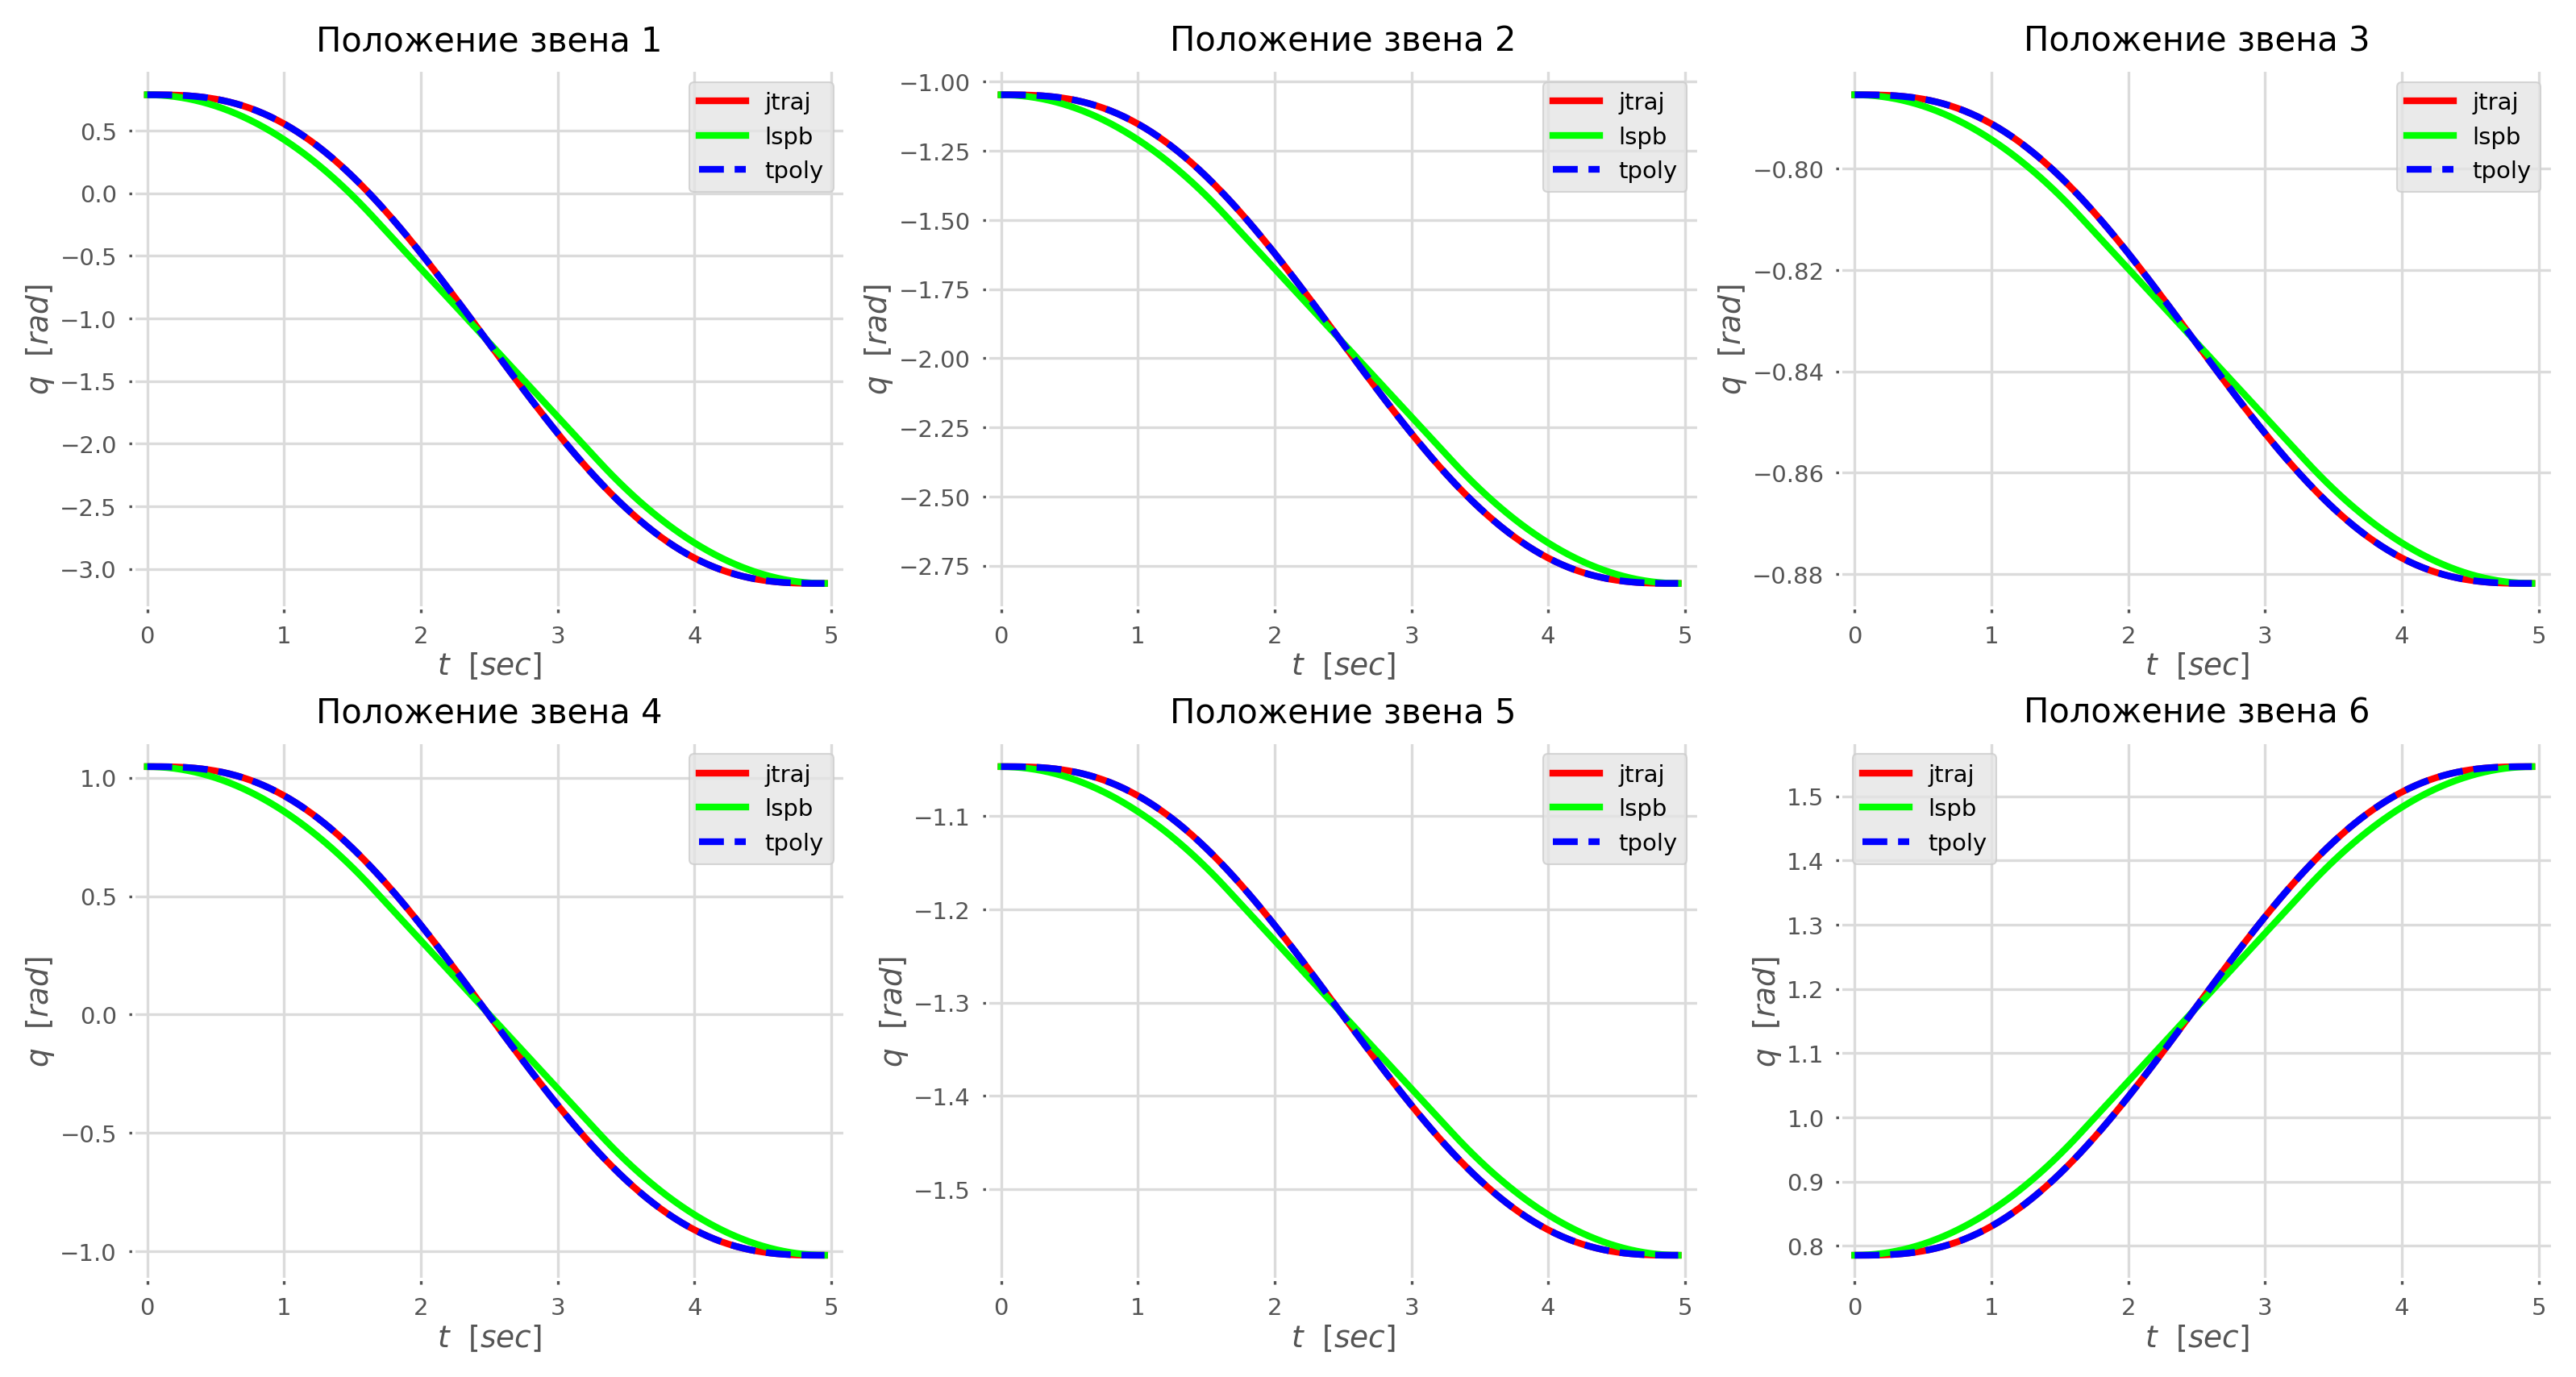

In [20]:
#Plot graphs of position of the robot's joints during trajectory motion
plt.figure(figsize=(10,5), dpi=300)  # Задаем размеры холста и плотность точек (четкость графика)
for g in range(1,7):
    plt.subplot(2,3,g)
    plt.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=0.2, hspace=0.25)  # Задаем интервалы между графиками, чтоб не перекрывали друг друга
    traektoriya_jtraj = [tr_jtraj.q[i][g-1] for i in range(len(tr_jtraj.q))]  # Извлекаем нужные данные
    traektoriya_trap = [tr_trap.q[i][g-1] for i in range(len(tr_trap.q))]  # Извлекаем нужные данные
    traektoriya_quin = [tr_quin.q[i][g-1] for i in range(len(tr_quin.q))]  # Извлекаем нужные данные
    plt.plot(time, traektoriya_jtraj, linestyle='-', linewidth=2, color=(1,0,0), label=r"jtraj")  # Рисуем линию
    plt.plot(time, traektoriya_trap, linestyle='-', linewidth=2, color=(0,1,0), label=r"lspb")  # Рисуем линию
    plt.plot(time, traektoriya_quin, linestyle='--', linewidth=2, color=(0,0,1), label=r"tpoly")  # Рисуем линию
    plt.title(r"Положение звена {}".format(g), fontsize=10)  # Название графика
    plt.ylabel(r"$q$  [$rad$]", fontsize=9)  # Подпись оси Y
    plt.xlabel(r"$t$  [$sec$]", fontsize=9)  # Подпись оси X
    plt.grid(True)  # Добавить сетку
    plt.legend()  # Отобразить легенду (покажет то, что написано в 'label')
    ax = plt.gca()  # gca = get current axis - чтобы редактировать конкретную фигуру
    ax.set_facecolor((1,1,1))  # Цвет фона на графике
    ax.set_xlim([t_start-0.1,t_stop+0.1])  # Пределы по оси X
plt.show()

Построим графики скоростей для каждого звена

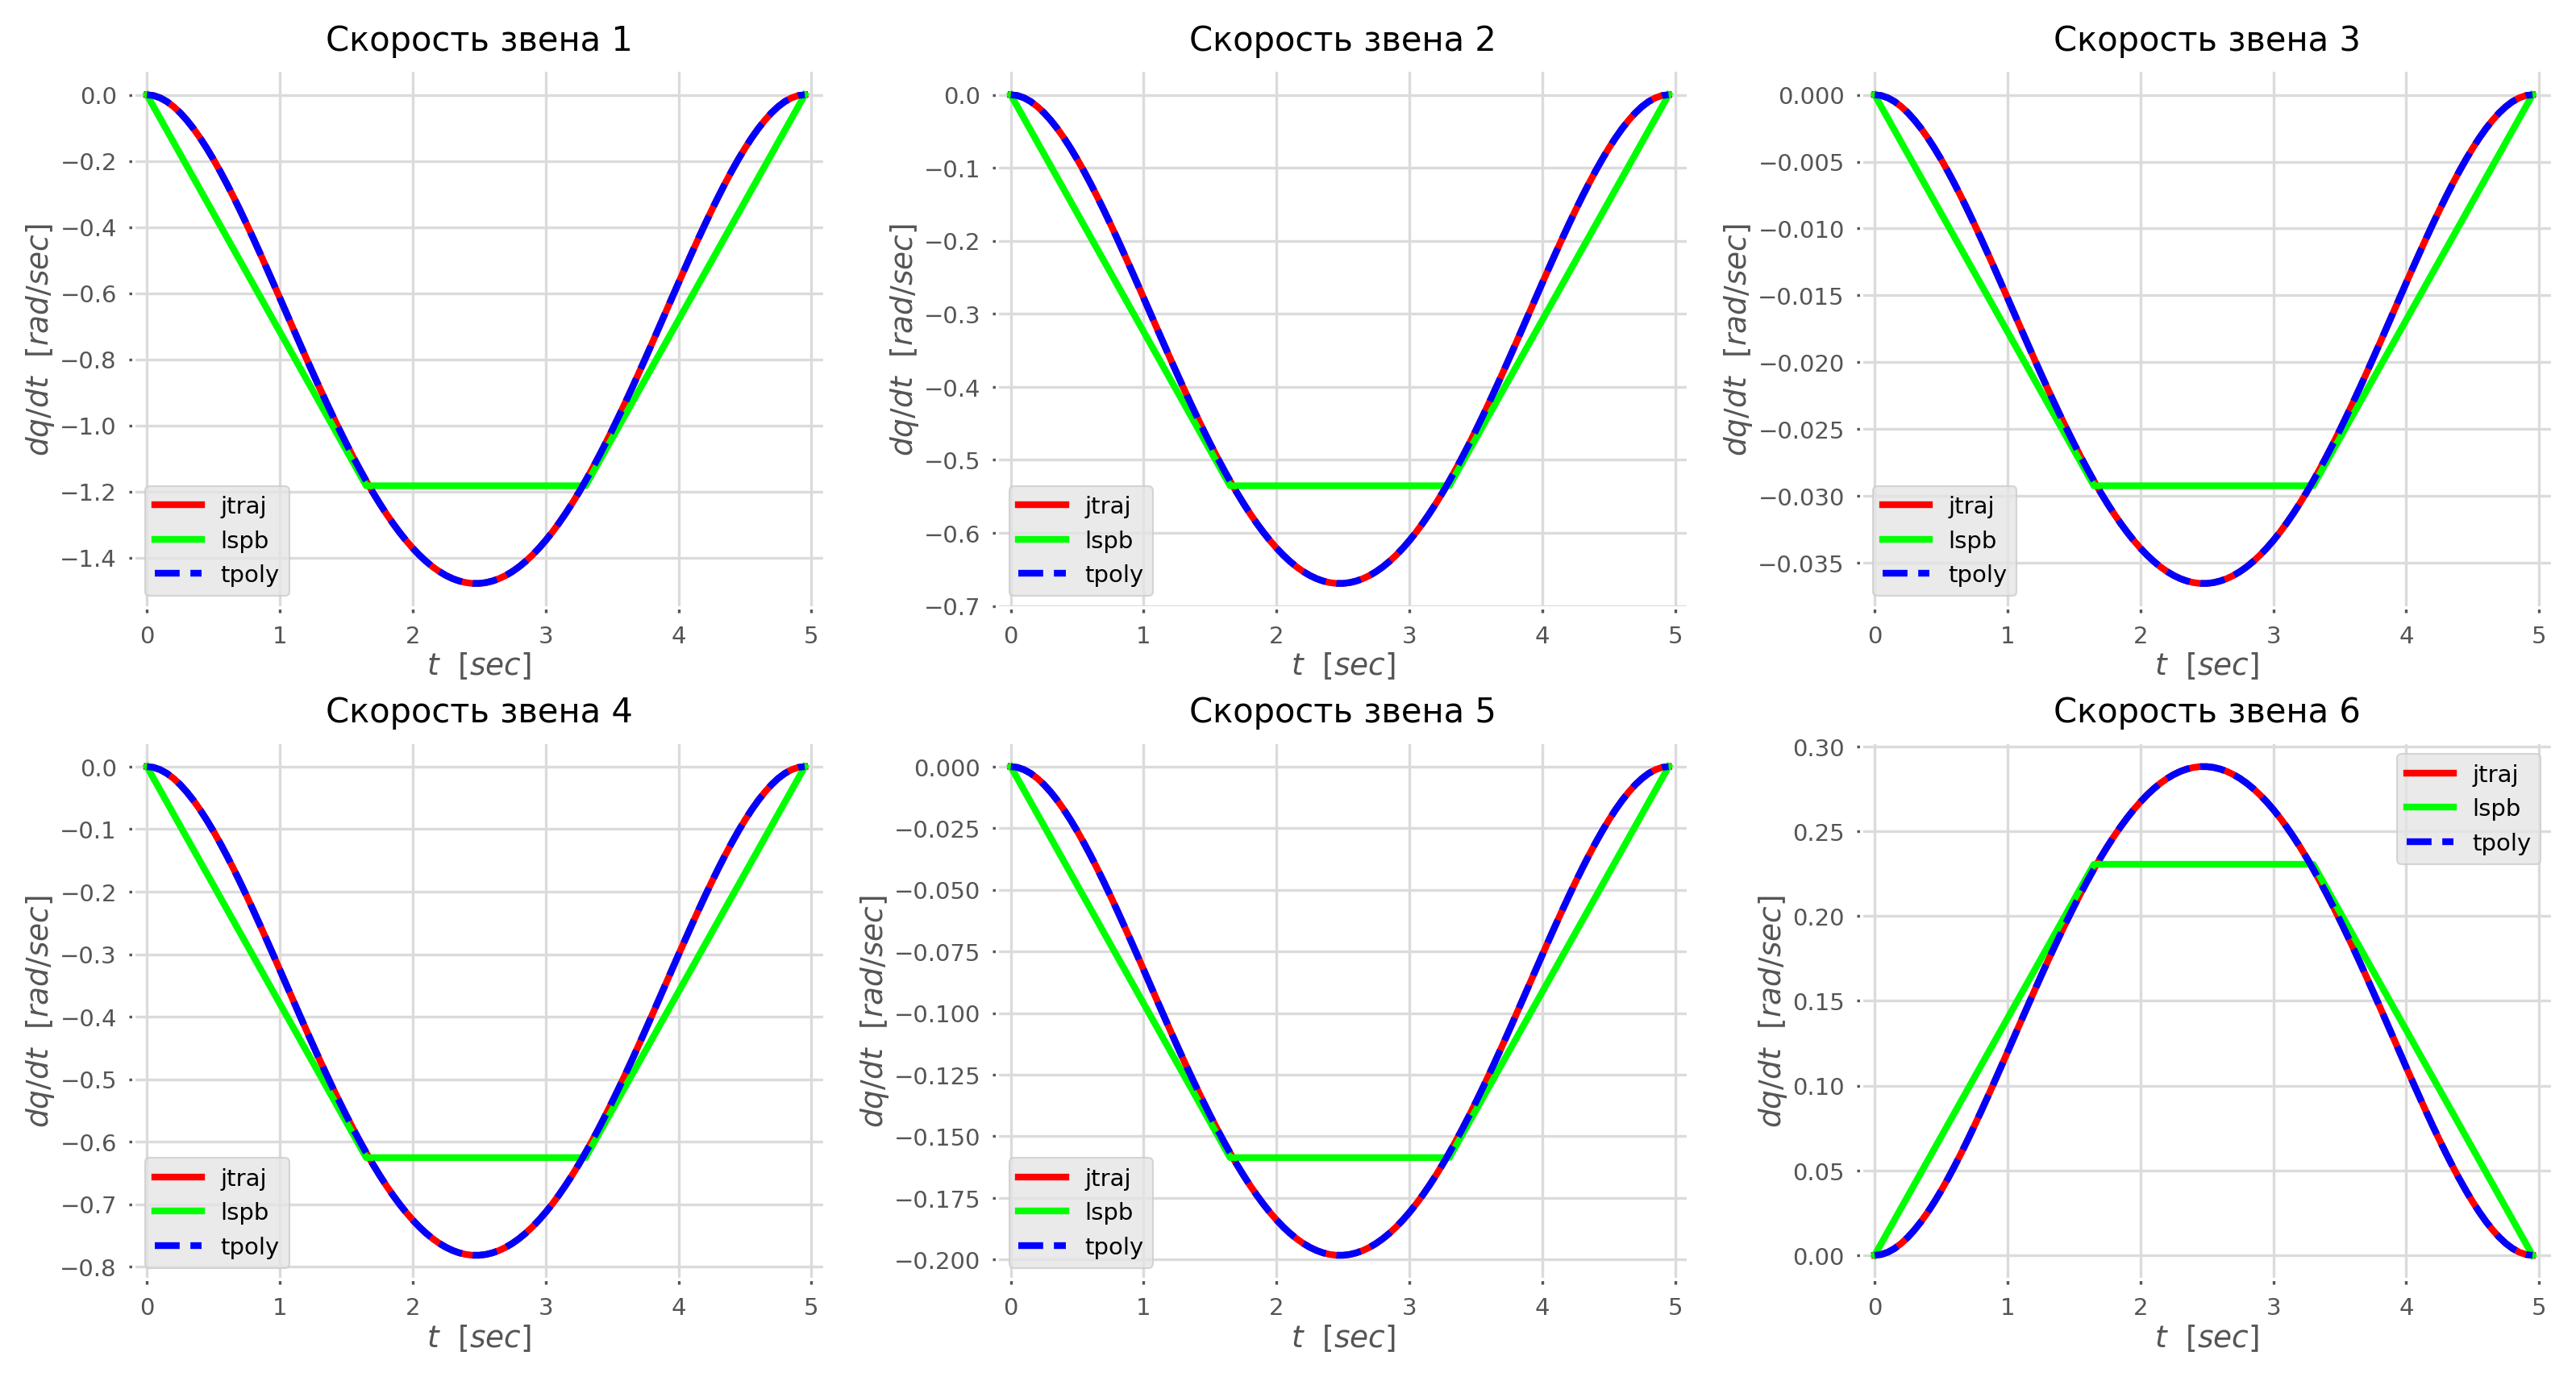

In [21]:
#Plot graphs of velocity of the robot's joints during trajectory motion
plt.figure(figsize=(10,5), dpi=300)  # Задаем размеры холста и плотность точек (четкость графика)
for g in range(1,7):
    plt.subplot(2,3,g)
    plt.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=0.25, hspace=0.25)  # Задаем интервалы между графиками, чтоб не перекрывали друг друга
    traektoriya_jtraj = [tr_jtraj.qd[i][g-1] for i in range(len(tr_jtraj.qd))]  # Извлекаем нужные данные
    traektoriya_trap = [tr_trap.qd[i][g-1] for i in range(len(tr_trap.qd))]  # Извлекаем нужные данные
    traektoriya_quin = [tr_quin.qd[i][g-1] for i in range(len(tr_quin.qd))]  # Извлекаем нужные данные
    plt.plot(time, traektoriya_jtraj, linestyle='-', linewidth=2, color=(1,0,0), label=r"jtraj")  # Рисуем линию
    plt.plot(time, traektoriya_trap, linestyle='-', linewidth=2, color=(0,1,0), label=r"lspb")  # Рисуем линию
    plt.plot(time, traektoriya_quin, linestyle='--', linewidth=2, color=(0,0,1), label=r"tpoly")  # Рисуем линию
    plt.title(r"Скорость звена {}".format(g), fontsize=10)  # Название графика
    plt.ylabel(r"$dq/dt$  [$rad/sec$]", fontsize=9)  # Подпись оси Y
    plt.xlabel(r"$t$  [$sec$]", fontsize=9)  # Подпись оси X
    plt.grid(True)  # Добавить сетку
    plt.legend()  # Отобразить легенду (покажет то, что написано в 'label')
    ax = plt.gca()  # gca = get current axis - чтобы редактировать конкретную фигуру
    ax.set_facecolor((1,1,1))  # Цвет фона на графике
    ax.set_xlim([t_start-0.1,t_stop+0.1])  # Пределы по оси X
plt.show()

Построим графики ускорений для каждого звена

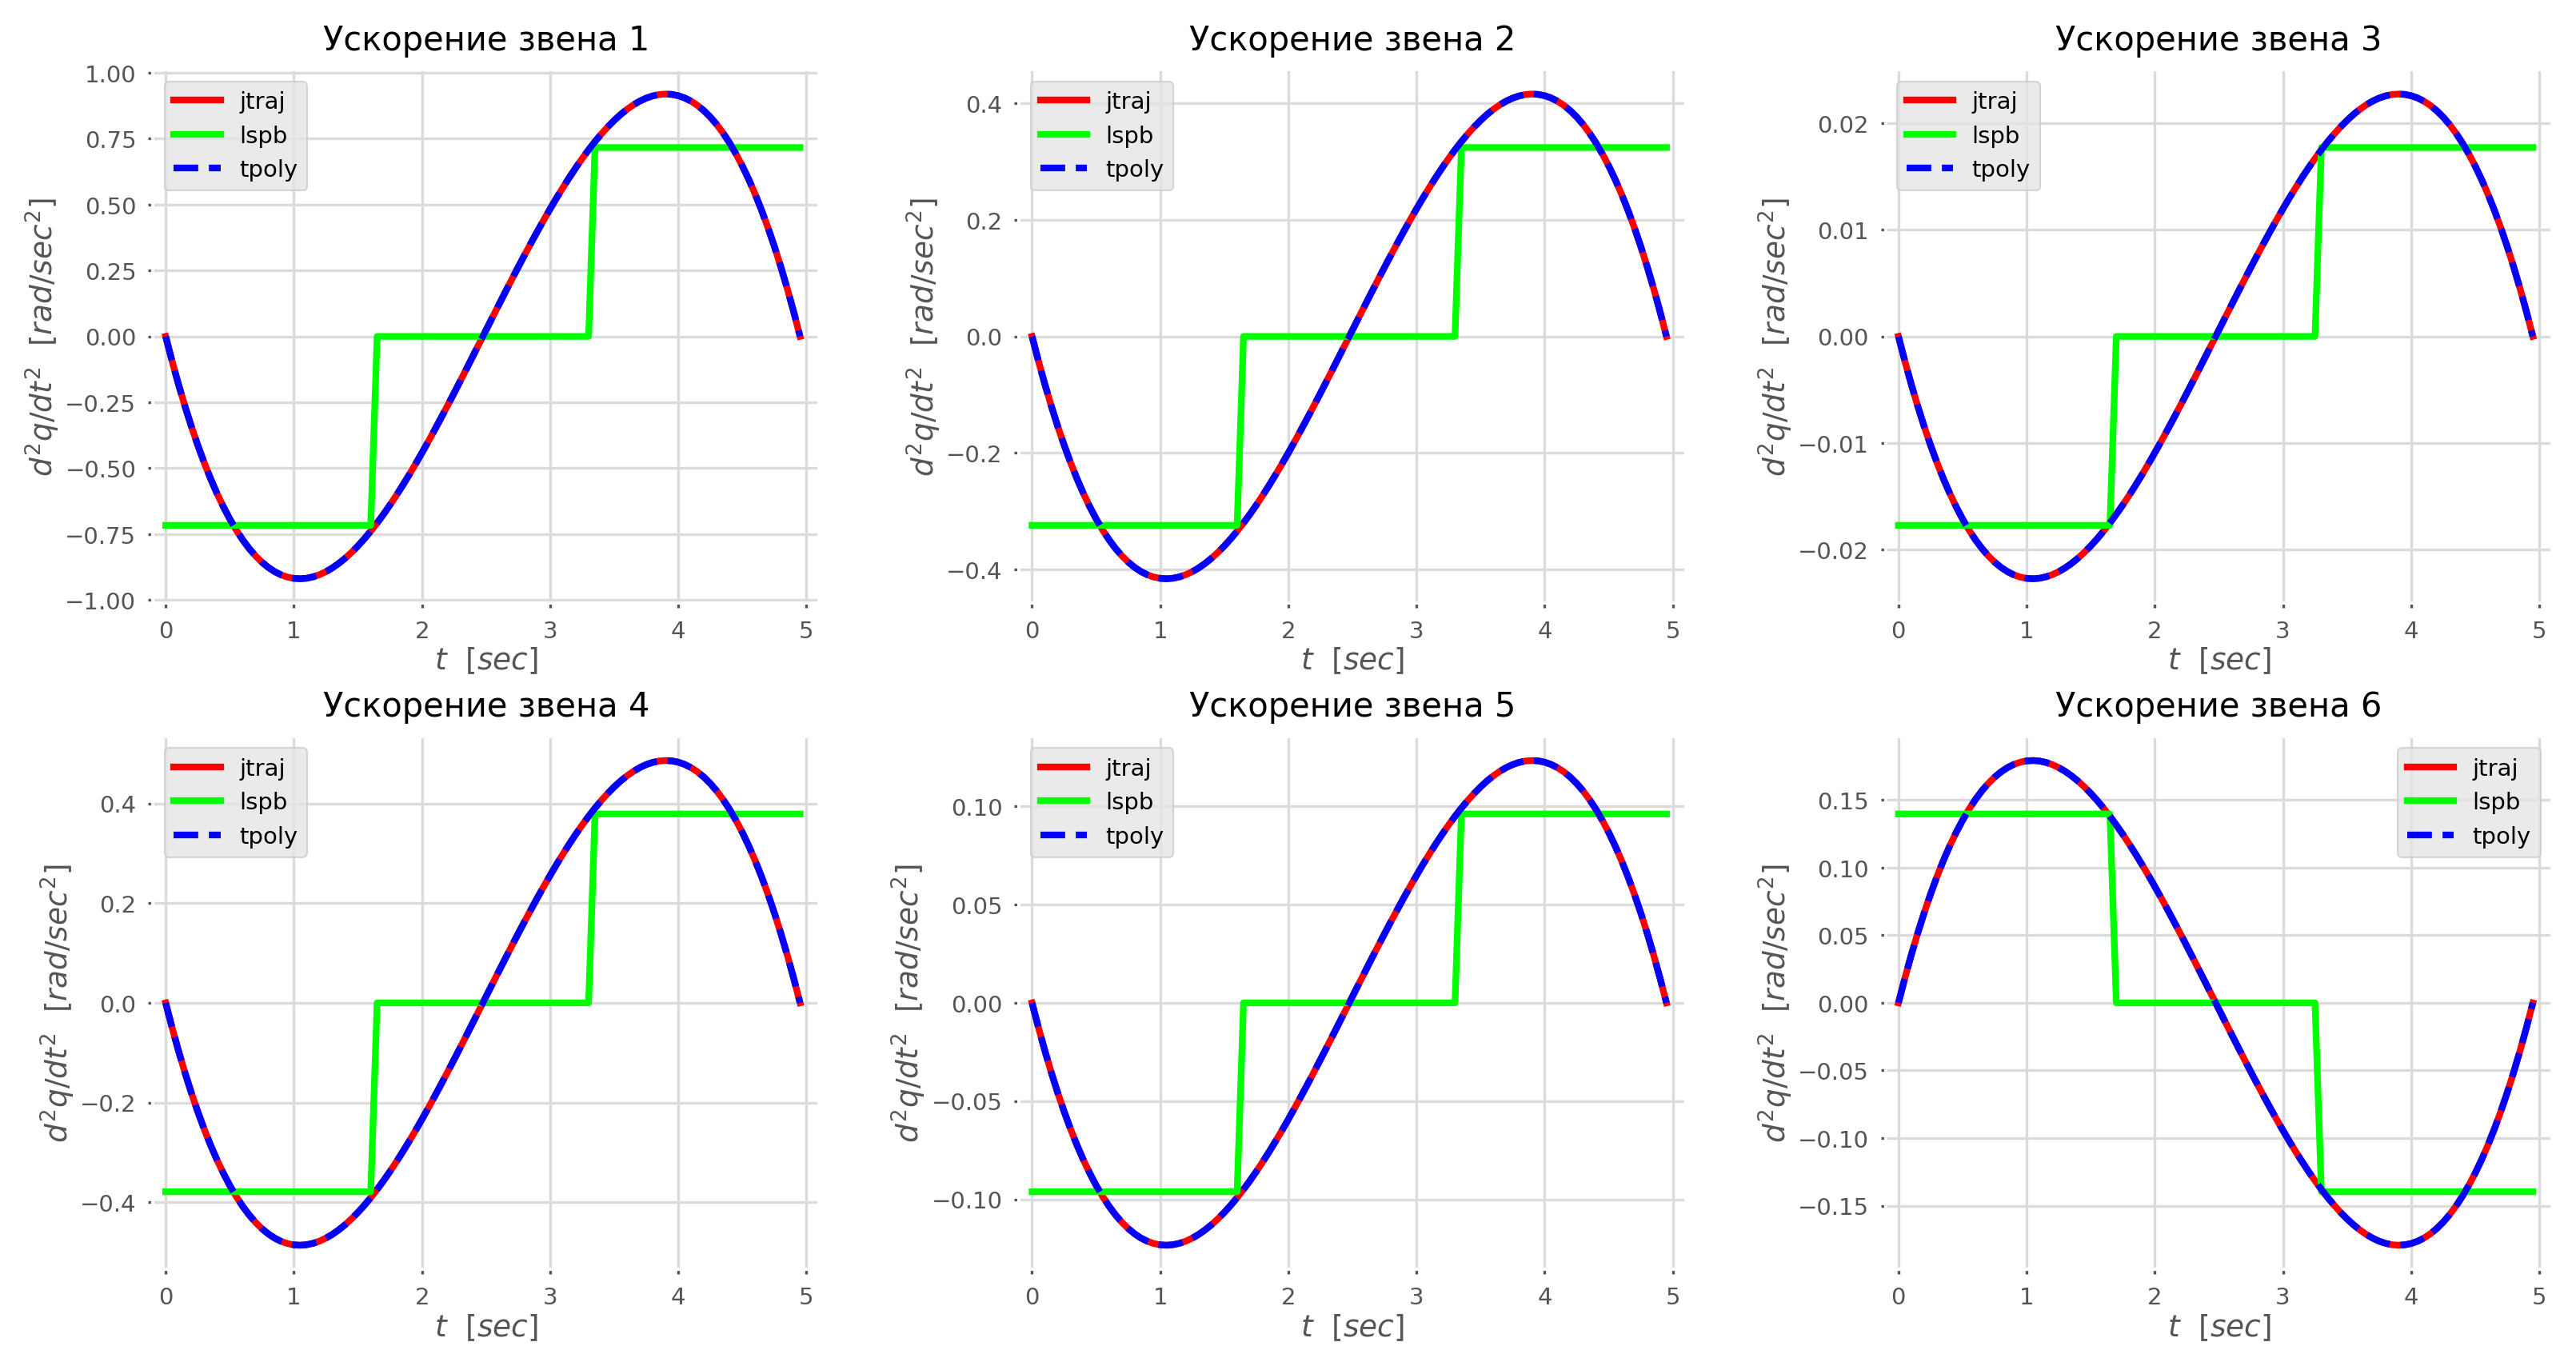

In [22]:
#Plot graphs of acceleration of the robot's joints during trajectory motion
fig = plt.figure(figsize=(10,5), dpi=300)  # Задаем размеры холста и плотность точек (четкость графика)
for g in range(1,7):
    plt.subplot(2,3,g)
    plt.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=0.3, hspace=0.25)  # Задаем интервалы между графиками, чтоб не перекрывали друг друга
    traektoriya_jtraj = [tr_jtraj.qdd[i][g-1] for i in range(len(tr_jtraj.qdd))]  # Извлекаем нужные данные
    traektoriya_trap = [tr_trap.qdd[i][g-1] for i in range(len(tr_trap.qdd))]  # Извлекаем нужные данные
    traektoriya_quin = [tr_quin.qdd[i][g-1] for i in range(len(tr_quin.qdd))]  # Извлекаем нужные данные
    plt.plot(time, traektoriya_jtraj, linestyle='-', linewidth=2, color=(1,0,0), label=r"jtraj")  # Рисуем линию
    plt.plot(time, traektoriya_trap, linestyle='-', linewidth=2, color=(0,1,0), label=r"lspb")  # Рисуем линию
    plt.plot(time, traektoriya_quin, linestyle='--', linewidth=2, color=(0,0,1), label=r"tpoly")  # Рисуем линию
    plt.title(r"Ускорение звена {}".format(g), fontsize=10)  # Название графика
    plt.ylabel(r"${d^2}q/d{t^2}$  [$rad/{sec}^2$]", fontsize=9)  # Подпись оси Y
    plt.xlabel(r"$t$  [$sec$]", fontsize=9)  # Подпись оси X
    plt.grid(True)  # Добавить сетку
    plt.legend()  # Отобразить легенду (покажет то, что написано в 'label')
    ax = plt.gca()  # gca = get current axis - чтобы редактировать конкретную фигуру
    ax.set_facecolor((1,1,1))  # Цвет фона на графике
    ax.set_xlim([t_start-0.1,t_stop+0.1])  # Пределы по оси X
plt.show()

## Discussion of Results

The UR3 manipulator model was loaded successfully from the Robotics Toolbox, and its Denavit-Hartenberg parameters were displayed. The initial joint configuration was selected arbitrarily within the allowed joint limits.

The forward kinematics result gives the end-effector pose corresponding to the selected initial joint coordinates. This confirms the relationship between the generalized coordinates and the Cartesian pose of the end-effector.

The workspace was constructed by varying the first three joints of the robot while keeping the wrist joints fixed. Therefore, the obtained workspace represents an approximate reachable region of the manipulator. The plotted workspace shows the possible positions that the end-effector can reach under the selected joint constraints.

A target point was selected inside the workspace, and the inverse kinematics problem was solved for this point. The obtained final joint configuration was then used as the target configuration for trajectory planning.

Three trajectory planning methods were used: jtraj, trapezoidal, and quintic. From the position plots, all methods move the joints from the initial configuration to the final configuration. The curves are smooth and continuous, which is important for stable robot motion.

The velocity plots show that the trapezoidal method has a more constant velocity part, while jtraj and quintic give smoother velocity profiles. The acceleration plots show the main differences between the methods. Smoother acceleration is usually better because it reduces sudden changes in motion and lowers mechanical stress on the robot joints.

Overall, the results show that different trajectory planning methods can reach the same final configuration, but they produce different velocity and acceleration behavior.